In [1]:
import sys, time, os
from matplotlib import colors, cm, rc
import matplotlib.pyplot as plt
from tqdm import tqdm
import corner

In [2]:
sys.path.insert(0, '../')

In [3]:
from theory import Pee_model
from forecast_utils import *
from parameters import telescope_specs
from utils import *
import triangleme2 as triangleme

In [4]:
props = dict(boxstyle="round", facecolor="white", alpha=0.5)
rc('font',**{'size': 16})
# rc('text', usetex=True)
rc('axes', linewidth = 1.5)

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [6]:
theta_labels = [r'$z_\mathrm{re}$', r'd$z$', r'log$\alpha_0$', r'$\kappa$']
prior_bounds = [(5.5, 10.), (0., 4.), (0, 6.), (0, 0.4)]

In [7]:
cos = cosmology.Planck18
ells = np.arange(1000, 8000, step=500)
low_ells = np.linspace(10, 100, 10)
print(ells.size, low_ells.size)

14 10


In [8]:
nsamples = 10000

In [20]:
ksz_emulator = 'RF'

In this notebook, we perform a Fisher forecast to better understand the results of our MCMC. Indeed, in a Fisher formalism, it is possible to derive the posterior distributions of the fit analytically.

# Fisher forecast

Given a posterior distribution $P(\theta\vert\mathrm{data})$ for model parameters $\theta$, the Fisher-matrix components are given by:
\begin{equation}
\mathcal{F}_{i j}=-\left\langle\frac{\partial^2 \ln P}{\partial \theta_i \partial \theta_j}\right\rangle.
\end{equation}
The Cramér-Rao theorem states that any unbiased estimator for the parameters will produce a covariance matrix that is no more accurate than $\mathcal{F}^{-1}$: thus the Fisher matrix can be used to estimate the minimum uncertainties of parameters given observations (e.g., Albrecht+2009).

Here, are observables are the patchy kSZ angular power spectrum $C_\ell^\mathrm{kSZ}$ at $\ell=3000$ and the dimensionless 21cm power spectrum $\Delta_{21}(k, z)$ at two points: $z=7.9$, $k=0.50\,\mathrm{Mpc}^{-1}$ and $z=10.4$, $k=0.53\,\mathrm{Mpc}^{-1}$. Let us gather these three data points in an observable vector $\mathbf{o}$ of dimension 3. We have $\mathbf{\Pi}$ the data covariance matrix of dimension (3, 3). Given the parameter set $\theta \equiv (z_{\mathrm{re}}, z_{\mathrm{end}})$, and assuming the posterior distribution can be described as Gaussian, we define the $(i, j)$ element of the Fisher matrix as
\begin{equation}
\mathcal{F}_{ij}= \frac{\partial \mathbf{o}^T}{\partial \theta_i}\mathbf{\Pi}^{-1}\frac{\partial \mathbf{o}}{\partial \theta_j}.
\end{equation}
In these ideal conditions, the inverse of the Fisher matric is the covariance matrix $\mathcal{C}=\mathcal{F}^{-1}$ and the forecast uncertainty of the $i$th parameter is $\sigma(\theta_i)=\sqrt{\mathcal{C}_{ii}}$.

## Data points and covariance matrix

Let's produce mock data points and covariance matrix.

In [9]:
theta_true = [7.0, 1.5, 3.7, 0.10]

In [ ]:
if os.path.exists(f'data/cv_limited_bb_datapoints.txt'):
    print('Reading from file...')
    ells_bb, bb_data = np.loadtxt(f'data/cv_limited_bb_datapoints.txt', unpack=True)
    ells_ksz, ksz_data = np.loadtxt(f'data/cv_limited_ksz_datapoints.txt', unpack=True)
    ells_tau, tau_data = np.loadtxt(f'data/cv_limited_tau_datapoints.txt', unpack=True)
    cov_ksz = np.loadtxt(f'data/cv_limited_cov_ksz.txt')
    cov_tau = np.loadtxt(f'data/cv_limited_cov_tau.txt')
    cov_bb = np.loadtxt(f'data/cv_limited_cov_bb.txt')
    ells = [ells_tau, ells_ksz, ells_bb]
else:
    ksz_data, tau_data, bb_data, cov_ksz, cov_tau, cov_bb = make_datapoints(
        theta_true, 
        ells, tel=telescope_specs['SO-LAT'],
        low_ells=low_ells, tel_lowl=telescope_specs['PICO'],
        cos=cos, save=None, use_ksz_emulator=ksz_emulator,
    )
icov_list = [np.linalg.inv(cov_ksz), np.linalg.inv(cov_tau), np.linalg.inv(cov_bb)]

Reading from file...


The error bars are drawn from the diagonal terms of the data covariance matrix $\mathbf{\Pi}$:

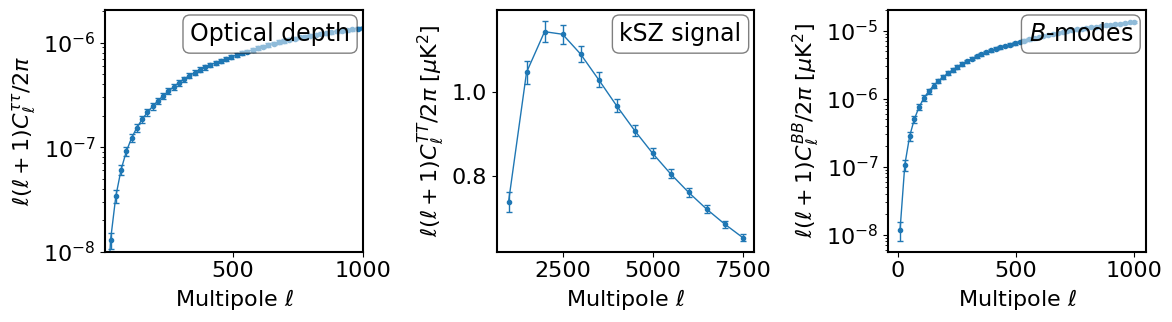

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

# tau
axes[0].errorbar(
    ells_tau, tau_data, yerr=np.sqrt(np.diag(cov_tau)),
    lw=1., marker='.', capsize=2.)
axes[0].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
axes[0].set_yscale('log')
# axes[0].set_xlim(0, 10000)
axes[0].set_ylim(bottom=1e-8)
axes[0].set_xlim(ells_tau.min(), ells_tau.max())

# ksz
axes[1].errorbar(
    ells_ksz, ksz_data, yerr=np.sqrt(np.diag(cov_ksz)),
    lw=1., marker='.', capsize=2.)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{TT}/2\pi$ [$\mu$K$^2$]')
# axes[1].set_xlim(ells.min(), 10000)
# axes[1].set_ylim(bottom=1e-2)
# axes[1].set_yscale('log')

# B-modes
axes[2].errorbar(
    ells_bb, bb_data, yerr=np.sqrt(np.diag(cov_bb)),
    lw=1., marker='.', capsize=2.)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# axes[2].set_ylim(bottom=1e-6)
# axes[2].set_xlim(low_ells.min(), low_ells.max())
axes[2].set_yscale('log')
# axes[2].set_xscale('log')

for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].text(0.95, 0.95, title, transform=axes[i].transAxes, fontsize=17, ha='right', va='top', bbox=props)
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_data.pdf', dpi=220)

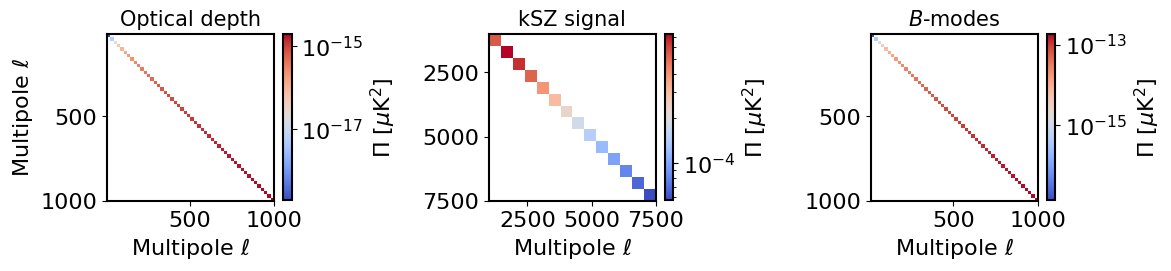

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (cov, title, l) in enumerate(zip([cov_tau, cov_ksz, cov_bb],
                                     ['Optical depth', 'kSZ signal', r'$B$-modes'],
                                     [ells_tau, ells_ksz, ells_bb])):
    norm = colors.LogNorm(np.diag(cov).min(), np.diag(cov).max())
    im = axes[i].imshow(cov, cmap='coolwarm', norm=norm,
                extent=(l.min(), l.max(), l.max(), l.min())
                )
    axes[i].set_title(title, fontsize=15)
    axes[i].set_xlabel(r'Multipole $\ell$')
    cbar = plt.colorbar(im, ax=axes[i], fraction=0.045, label=r'$\Pi$ [$\mu$K$^2$]')
axes[0].set_ylabel(r'Multipole $\ell$')
fig.tight_layout()

In [14]:
icov_tau = np.linalg.inv(cov_tau)
icov_ksz = np.linalg.inv(cov_ksz)
icov_bb = np.linalg.inv(cov_bb)

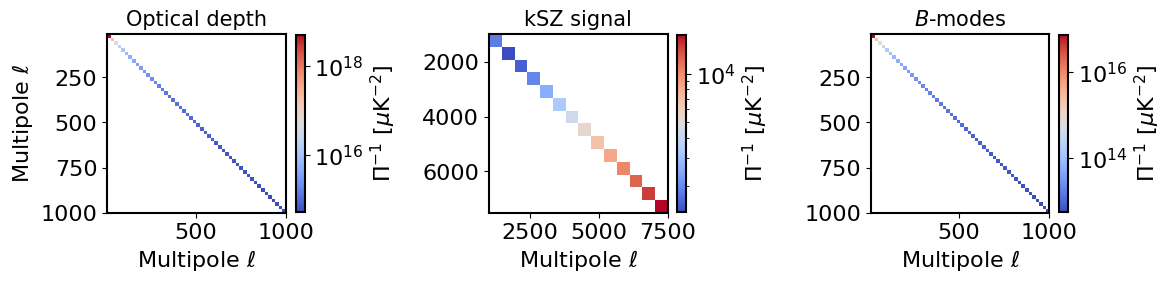

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (icov, title, l) in enumerate(zip([icov_tau, icov_ksz, icov_bb],
                                     ['Optical depth', 'kSZ signal', r'$B$-modes'],
                                     [ells_tau, ells_ksz, ells_bb])):
    norm = colors.LogNorm(np.diag(icov).min(), np.diag(icov).max())
    im = axes[i].imshow(icov, cmap='coolwarm', norm=norm,
                extent=(l.min(), l.max(), l.max(), l.min()))
    axes[i].set_xlabel(r'Multipole $\ell$')
    axes[i].set_title(title, fontsize=15)
    cbar = plt.colorbar(im, ax=axes[i], fraction=0.045, label=r'$\Pi^{-1}$ [$\mu$K$^{-2}$]')
axes[0].set_ylabel(r'Multipole $\ell$')
fig.tight_layout()

## Derivatives

Let us use the approximation:
\begin{equation}
\frac{\partial f}{\partial x}\biggr\rvert_{x_0,y_0} \simeq \frac{f(x_0+\Delta x, y_0)-f(x_0-\Delta x, y_0)}{2 \Delta x}
\end{equation}
for $\Delta x \ll x_0$.

We will get the derivative at $\pm 5\%$ from the central value.

In [16]:
dev = 0.05 # %

In [52]:
t0 = time.time()
deriv_list = get_derivatives(theta_true, ells, run_derivatives=True, dev=dev, use_ksz_emulator=ksz_emulator)
t1 = time.time()
print(f'Took {(t1-t0)/60.:.1f} mins.')

0
1
2
3
Took 2.5 mins.


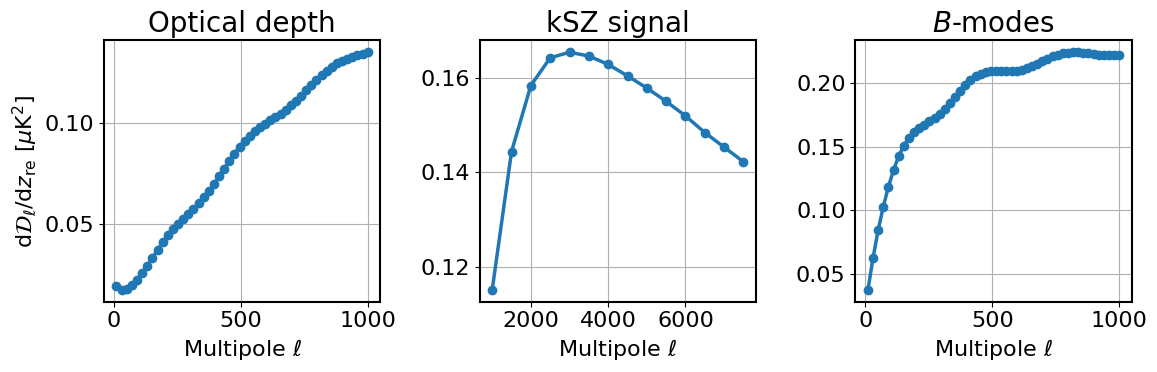

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))#, sharey=True)

# tau
axes[0].plot(ells_tau, deriv_list[0][1]/tau_data, ls='-', color='C0', lw=2.5, marker='o')
axes[0].set_xlabel(r'Multipole $\ell$')

# ksz
axes[1].plot(ells_ksz, deriv_list[0][0]/ksz_data, lw=2.5, marker='o')
axes[1].set_xlabel(r'Multipole $\ell$')
# axes[1].set_ylim(bottom=1e-2)

# B-modes
axes[2].plot(ells_bb, deriv_list[0][2]/bb_data, lw=2.5, marker='o')
axes[2].set_xlabel(r'Multipole $\ell$')
# axes[2].set_xlim(30, low_ells.max())

axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$z_\mathrm{re}$ [$\mu$K$^2$]')
for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
fig.tight_layout()

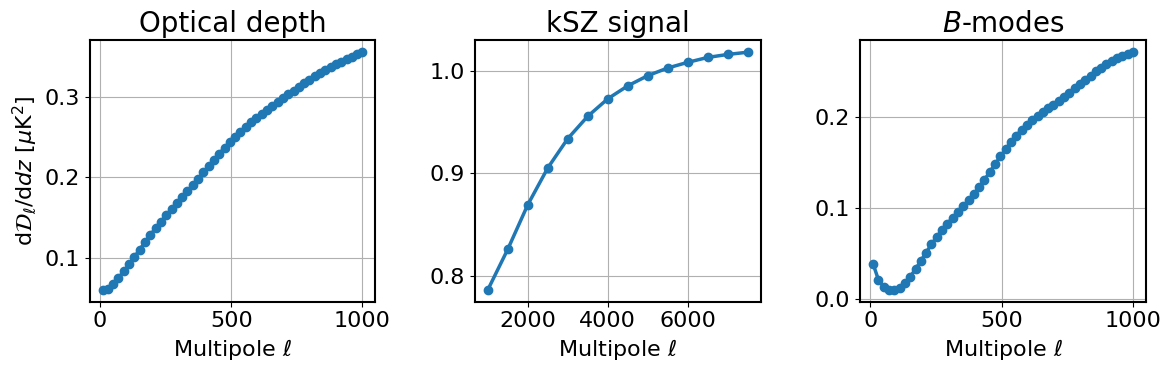

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))#, sharey=True)

# tau
axes[0].plot(ells_tau, deriv_list[1][1]/tau_data, ls='-', color='C0', lw=2.5, marker='o')
axes[0].set_xlabel(r'Multipole $\ell$')
# axes[0].set_xlim(0, 10000)

# ksz
axes[1].plot(ells_ksz, deriv_list[1][0]/ksz_data, lw=2.5, marker='o')
axes[1].set_xlabel(r'Multipole $\ell$')
# axes[1].set_ylim(0, 1)

# B-modes
axes[2].plot(ells_bb, deriv_list[1][2]/bb_data, lw=2.5, marker='o')
axes[2].set_xlabel(r'Multipole $\ell$')
# axes[2].set_xlim(30, low_ells.max())

axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$dz$ [$\mu$K$^2$]')
for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
fig.tight_layout()

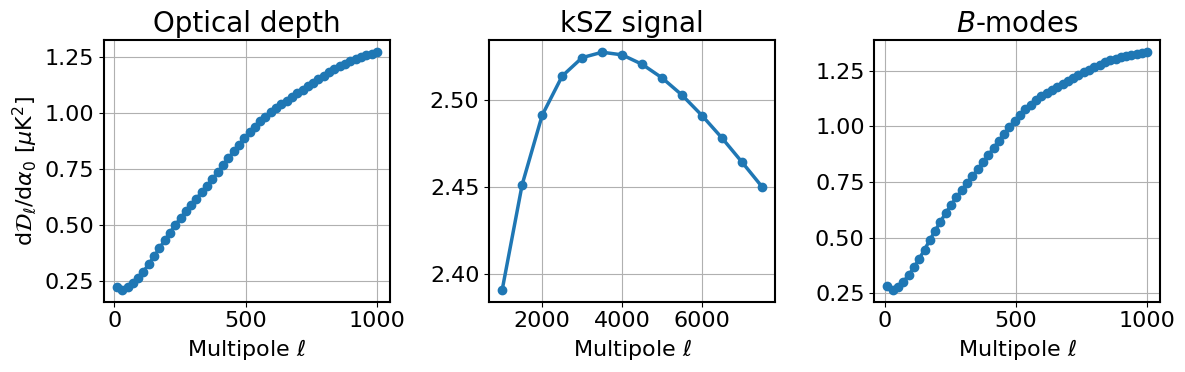

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))#, sharey=True)

# tau
axes[0].plot(ells_tau, deriv_list[2][1]/tau_data, ls='-', color='C0', lw=2.5, marker='o')
axes[0].set_xlabel(r'Multipole $\ell$')
# axes[0].set_xlim(0, 10000)

# ksz
axes[1].plot(ells_ksz, deriv_list[2][0]/ksz_data, lw=2.5, marker='o')
axes[1].set_xlabel(r'Multipole $\ell$')
# axes[1].set_ylim(0, 1)

# B-modes
axes[2].plot(ells_bb, deriv_list[2][2]/bb_data, lw=2.5, marker='o')
axes[2].set_xlabel(r'Multipole $\ell$')
# axes[2].set_xlim(30, low_ells.max())

axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$\alpha_0$ [$\mu$K$^2$]')
for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
fig.tight_layout()

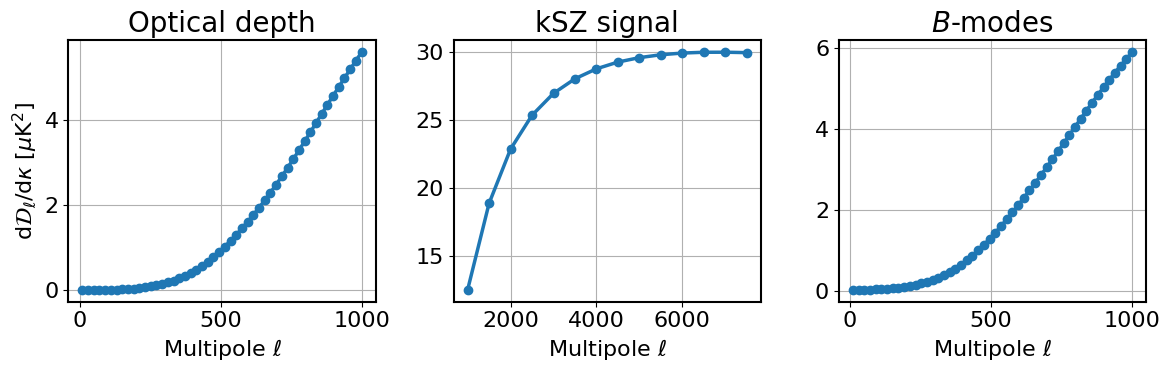

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))#, sharey=True)

# tau
axes[0].plot(ells_tau, deriv_list[3][1]/tau_data, ls='-', color='C0', lw=2.5, marker='o')
axes[0].set_xlabel(r'Multipole $\ell$')
# axes[0].set_xlim(0, 10000)

# ksz
axes[1].plot(ells_ksz, deriv_list[3][0]/ksz_data, lw=2.5, marker='o')
axes[1].set_xlabel(r'Multipole $\ell$')
# axes[1].set_ylim(0, 1)

# B-modes
axes[2].plot(ells_bb, deriv_list[3][2]/bb_data, lw=2.5, marker='o')
axes[2].set_xlabel(r'Multipole $\ell$')
# axes[2].set_xlim(30, low_ells.max())

axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$\kappa$ [$\mu$K$^2$]')
for i, (letter, title) in enumerate(zip(['a', 'b', 'c'],
                                        ['Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
fig.tight_layout()

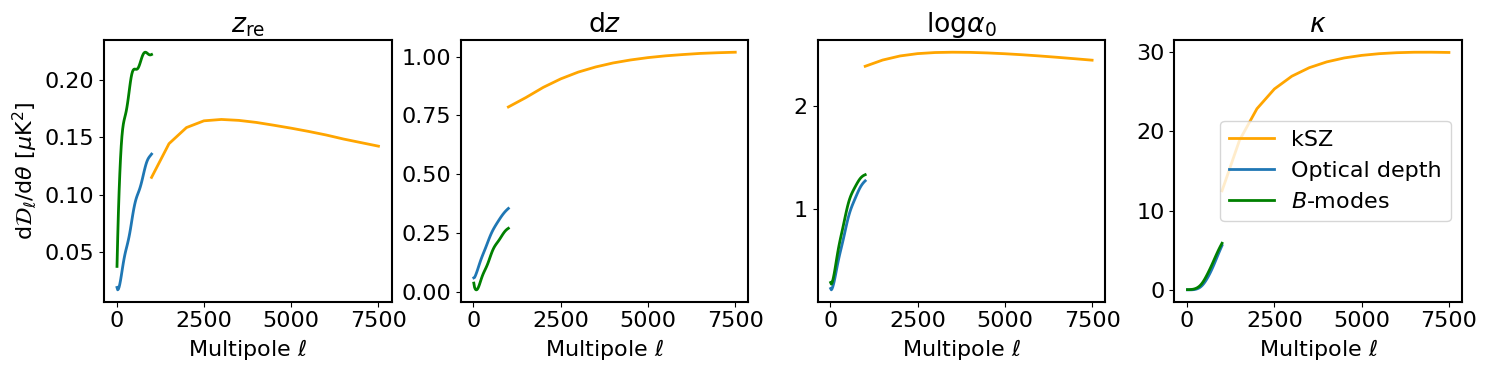

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for j, name in enumerate(theta_labels):

    for i, (deriv, color, obs, ref, ls) in enumerate(zip(
            deriv_list[j],
            ['orange', 'C0', 'green'],
            ['kSZ', r'Optical depth', r'$B$-modes'],
            [ksz_data, tau_data, bb_data],
            [ells[1], ells[0], ells[2]])):
        axes[j].plot(ls, deriv/ref, color=color, label=obs, lw=2.)

    axes[j].set_title(name)
    axes[j].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$\theta$ [$\mu$K$^2$]')
axes[-1].legend()
fig.tight_layout()

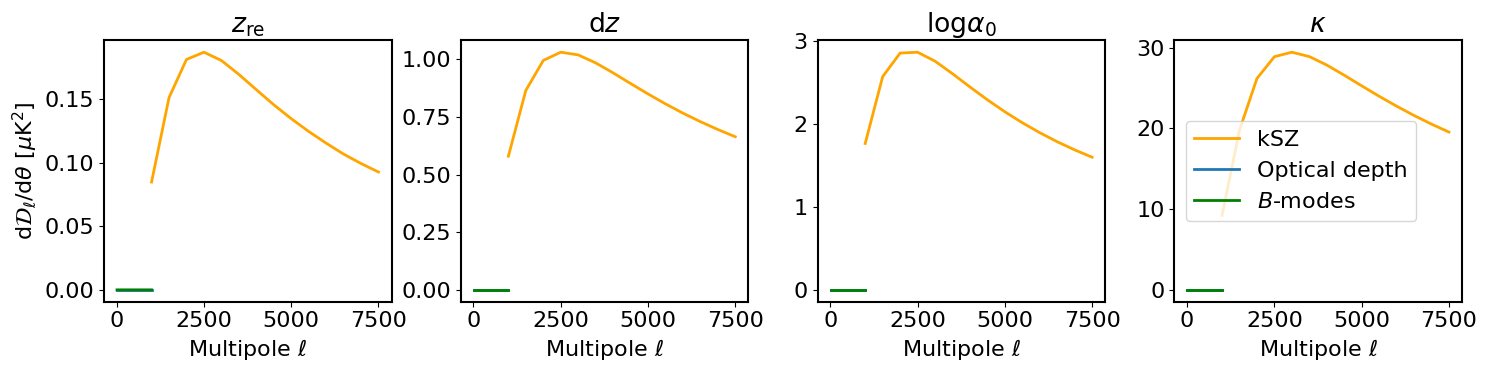

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for j, name in enumerate(theta_labels):

    for i, (deriv, color, obs, ref, ls) in enumerate(zip(
            deriv_list[j],
            ['orange', 'C0', 'green'],
            ['kSZ', r'Optical depth', r'$B$-modes'],
            [ksz_data, tau_data, bb_data],
            [ells[1], ells[0], ells[2]])):
        axes[j].plot(ls, deriv, color=color, label=obs, lw=2.)
    axes[j].set_title(name)
    axes[j].set_xlabel(r'Multipole $\ell$')
axes[0].set_ylabel(r'd$\mathcal{D}_\ell/$d$\theta$ [$\mu$K$^2$]')
axes[-1].legend()
fig.tight_layout()

## Fisher and covariance matrix

Applying the equations above giving the Fisher matrix in terms of the derivative of the observables with respect to model parameters, we get:

### Fisher for kSZ

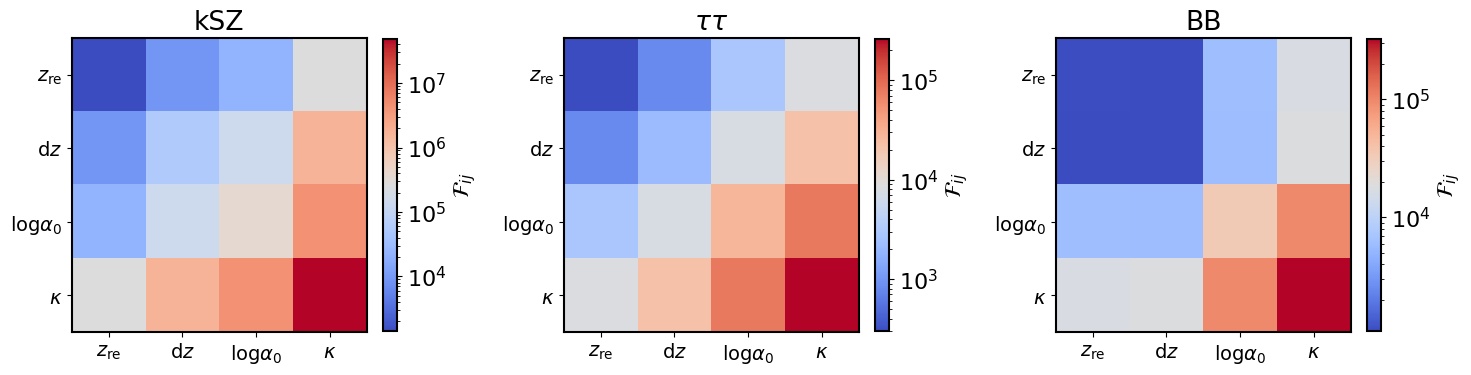

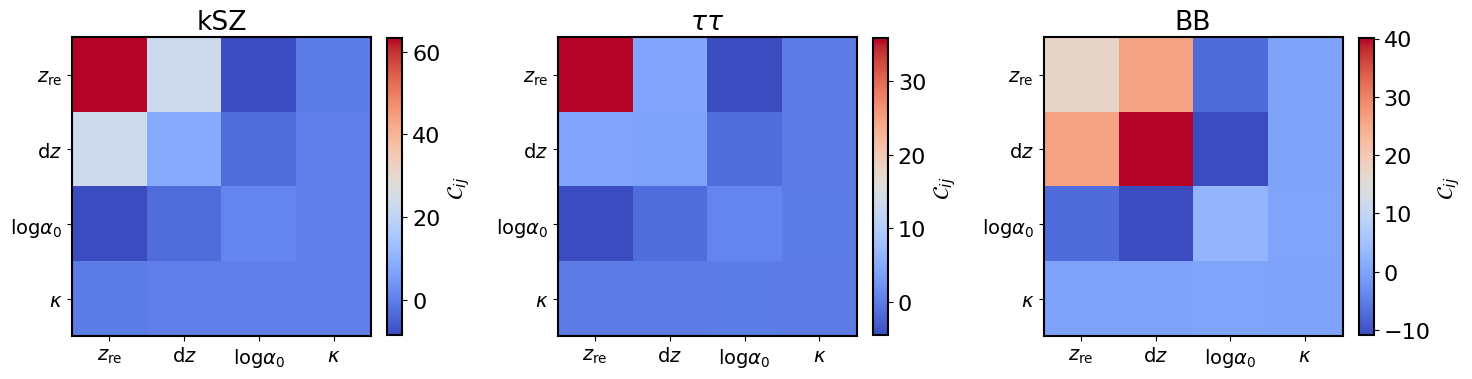

In [29]:
# fisher
fishcov_list = []
fishmat_list = []
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

for io, obs in enumerate(['kSZ', r'$\tau\tau$', 'BB']):
    fishmat = np.zeros((len(theta_true), len(theta_true)))
    for i, deriv in enumerate([d[io] for d in deriv_list]):
        for j, deriv2 in enumerate([d[io] for d in deriv_list]):
            fishmat[i, j] = np.transpose(deriv).dot(icov_list[io]).dot(deriv2)
    fishmat_list.append(fishmat)
    fishcov = np.linalg.inv(fishmat)
    assert np.allclose(np.dot(fishmat, fishcov), np.eye(len(theta_true)), atol=1e-6)
    fishcov_list.append(fishcov)

    # figures
    im = axes[io].imshow(fishmat, cmap='coolwarm', norm=colors.LogNorm(),
                extent=(0, 2, 2, 0))
    axes[io].set_xticks(np.arange(0.25, 2, step=.5),
                labels=theta_labels, fontsize=14)
    axes[io].set_yticks(np.arange(0.25, 2, step=.5),
                labels=theta_labels, fontsize=14)
    cbar = plt.colorbar(im, ax=axes[io], fraction=0.045, label=r'$\mathcal{F}_{ij}$')
    axes[io].set_title(obs)

    im = axes2[io].imshow(fishcov, cmap='coolwarm', #norm=colors.LogNorm(),
                extent=(0, 2, 2, 0))
    axes2[io].set_xticks(np.arange(0.25, 2, step=.5),
                labels=theta_labels, fontsize=14)
    axes2[io].set_yticks(np.arange(0.25, 2, step=.5),
                labels=theta_labels, fontsize=14)
    cbar = plt.colorbar(im, ax=axes2[io], fraction=0.045, label=r'$\mathcal{C}_{ij}$')
    axes2[io].set_title(obs)

fig.tight_layout()
fig2.tight_layout()


In [30]:
[np.sqrt(np.linalg.det(fishmat_list[i])) for i in range(3)]  # figures of merit

[279775.05537089106, 2975.866080931568, 12975.23085052704]

In [31]:
[np.sqrt(np.linalg.det(fishmat_list[i][:2, :2])) for i in range(3)]

[743.5006441642523, 30.093497187455903, 269.5132697623816]

In [32]:
[np.sqrt(np.linalg.det(fishmat_list[i][2:, 2:])) for i in range(3)]

[449122.7499131515, 32927.89725551815, 38362.86619369101]

Now we can define a distribution, given the "true" values of each model parameters and the above covariance matrix.

In [33]:
data_ksz = np.random.multivariate_normal(theta_true, fishcov_list[0], size=nsamples)
data_tau = np.random.multivariate_normal(theta_true, fishcov_list[1], size=nsamples)
data_bb = np.random.multivariate_normal(theta_true, fishcov_list[2], size=nsamples)

The forecast posterior distributions are plotted in a triangle plot:

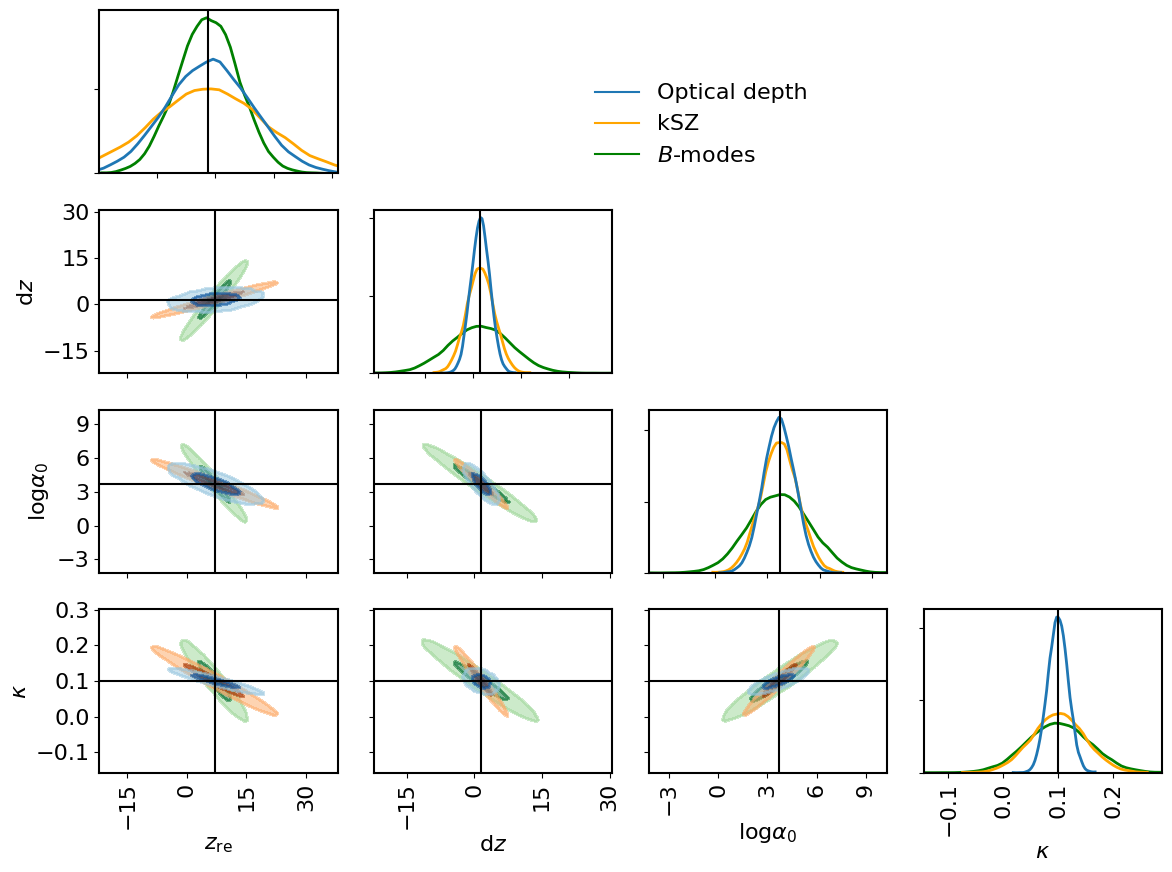

In [60]:
bounds = [(0, 50), (0, 15), (0, 10), (0, 0.3)]
zorders = [0, 1, 2, 3]
fig, axes = plt.subplots(4, 4, figsize=(12, 9))
triangleme.corner(data_tau,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Blues', color='C0', lw=2., smooth=1., alpha=.5,
                #   extents=bounds, 
                  truths=theta_true, 
                  zorder=zorders[2],truth_color='k', 
                  fig=fig)

triangleme.corner(data_ksz, #corrcoef=True,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Oranges', color='orange', lw=2., smooth=1., alpha=.5,
                #   extents=bounds, 
                  labels=theta_labels,
                  zorder=zorders[1],
                  fig=fig)

triangleme.corner(data_bb,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greens', color='green', lw=2., smooth=1., alpha=.5,
                  # extents=bounds, 
                  zorder=zorders[0],
                  fig=fig)
plt.plot([], [], color='C0', label='Optical depth')
plt.plot([], [], color='orange', label='kSZ')
plt.plot([], [], color='green', label=r'$B$-modes')
# plt.plot([], [], color='k', label=r'All')
fig.legend(loc=(0.5, 0.8), frameon=False)

fig.tight_layout()
# fig.savefig('figures/fisher_forecast_comparison_ideal.pdf', dpi=200)

### Combination

In [98]:
# fishcov_all = combined_forecast(
#         theta_true, ells, low_ells,
#         index_list=[0, 1, 2],
#         tel=telescope_specs['CMB-HD'], cos=cosmology.Planck18,
#         run_derivatives=False, dev=0.05
#     )

In [54]:
index_list = [0, 1, 2]  # combine all observables

cov_list = [[cov_tau, cov_ksz, cov_bb][i] for i in index_list]
cov_tot = np.diag( np.hstack([np.diag(cov) for cov in cov_list]) )
icov_tot = np.linalg.inv(cov_tot)

# derivatives
# deriv_list_temp = get_derivatives(theta_true, ells, run_derivatives=True, dev=dev, use_ksz_emulator=ksz_emulator)
# # remove obs not used
# deriv_list = []
# for l in deriv_list_temp:
#     deriv_list.append([l[i] for i in index_list])
#     # l = [deriv_tau_zre, deriv_ksz_zre, deriv_bb_zre]

fish_all = np.zeros((len(theta_true), len(theta_true)))
for i, deriv in enumerate([np.hstack(l) for l in deriv_list]):
    for j, deriv2 in enumerate([np.hstack(l) for l in deriv_list]):
        fish_all[i, j] = np.transpose(deriv).dot(icov_tot).dot(deriv2)
fishcov_all = np.linalg.inv(fish_all)

data_all = np.random.multivariate_normal(theta_true, fishcov_all, size=nsamples)

In [40]:
# index_list = [0, 2]  # combine all observables

# cov_list = [[cov_ksz, cov_tau, cov_bb][i] for i in index_list]
# cov_tot = np.diag( np.hstack([np.diag(cov) for cov in cov_list]) )
# icov_tot = np.linalg.inv(cov_tot)

# # derivatives
# deriv_list_temp = get_derivatives(theta_true, ells, run_derivatives=True, dev=dev, use_ksz_emulator=ksz_emulator)
# # remove obs not used
# deriv_list = []
# for l in deriv_list_temp:
#     deriv_list.append([l[i] for i in index_list])
#     # l = [deriv_tau_zre, deriv_ksz_zre, deriv_bb_zre]

# fish_notau = np.zeros((len(theta_true), len(theta_true)))
# for i, deriv in enumerate([np.hstack(l) for l in deriv_list]):
#     for j, deriv2 in enumerate([np.hstack(l) for l in deriv_list]):
#         fish_notau[i, j] = np.transpose(deriv).dot(icov_tot).dot(deriv2)
# fishcov_notau = np.linalg.inv(fish_notau)

# data_notau = np.random.multivariate_normal(theta_true, fishcov_notau, size=nsamples)

0


KeyboardInterrupt: 

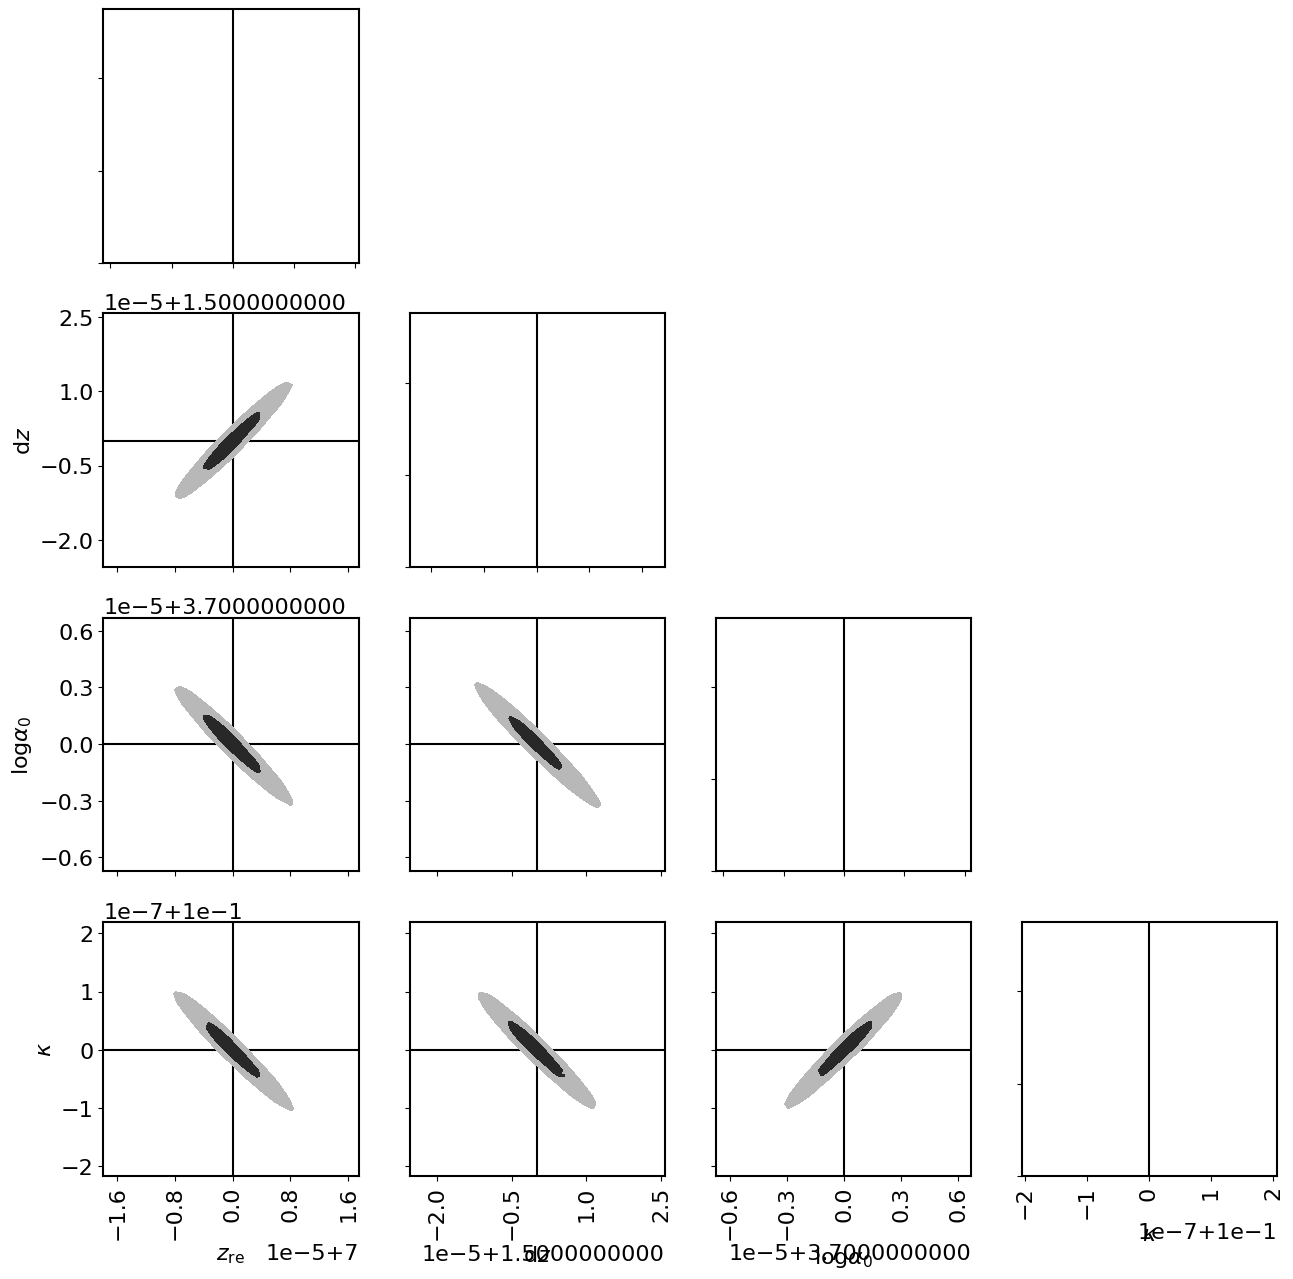

In [55]:
_ = triangleme.corner(data_all, plot_hist=False,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greys', color='k', lw=2., smooth=1., alpha=1,
                #   extents=bounds, 
                  zorder=zorders[3],
                  truths=theta_true, truth_color='k',
)

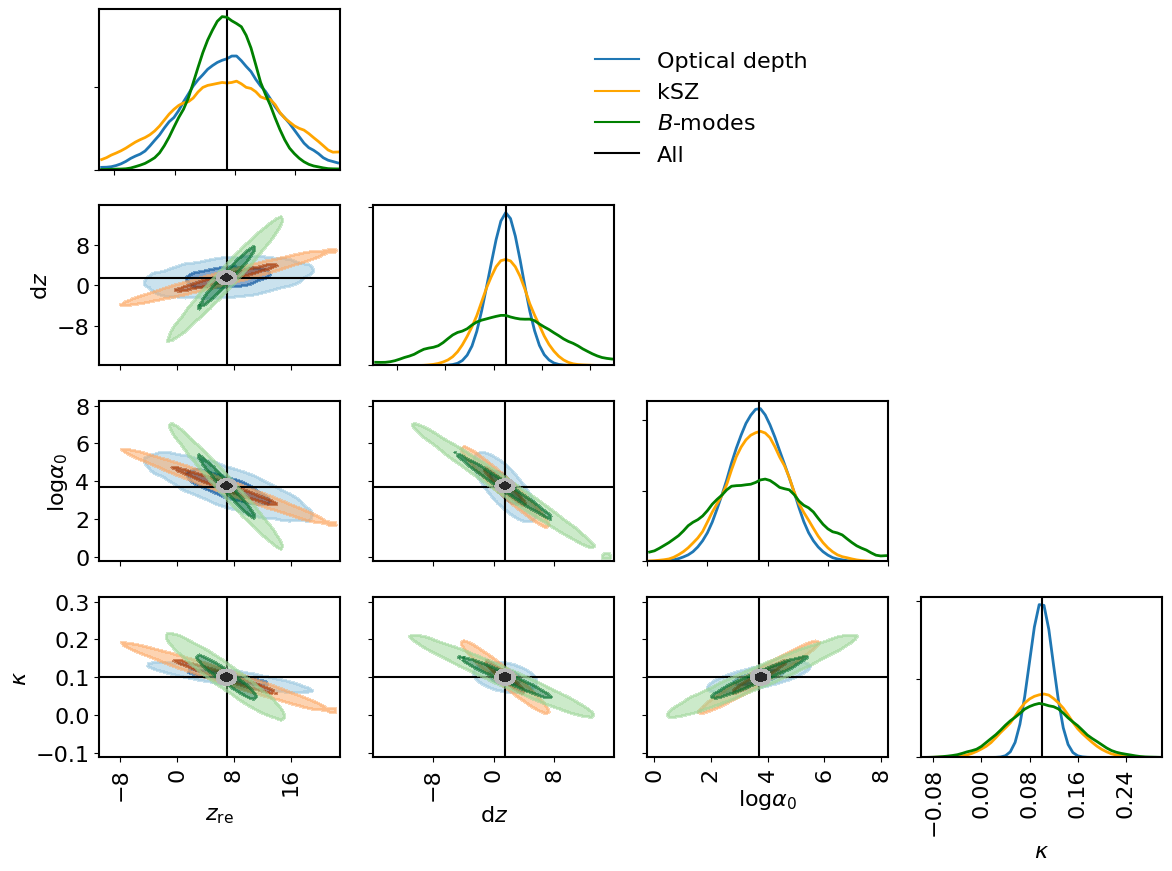

In [61]:
extents = [(-10, 22), (-15, 15), (0, 8), (-0.1, 0.3)]
zorders = [0, 1, 2, 3]
fig, axes = plt.subplots(4, 4, figsize=(12, 9))
triangleme.corner(data_all, plot_hist=False,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greys', color='k', lw=2., smooth=1., alpha=1,
                  extents=extents, 
                  zorder=zorders[3],
                  truths=theta_true, truth_color='k',
                  fig=fig)
triangleme.corner(data_tau,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Blues', color='C0', lw=2., smooth=1., alpha=.5,
                  extents=extents, 
                  zorder=zorders[0],truth_color='k', 
                  fig=fig)
triangleme.corner(data_ksz, #corrcoef=True,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Oranges', color='orange', lw=2., smooth=1., alpha=.5,
                  extents=extents, 
                  zorder=zorders[1],
                  fig=fig)
triangleme.corner(data_bb,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greens', color='green', lw=2., smooth=1., alpha=.5,
                  extents=extents, 
                  zorder=zorders[2],
                  fig=fig)
plt.plot([], [], color='C0', label='Optical depth')
plt.plot([], [], color='orange', label='kSZ')
plt.plot([], [], color='green', label=r'$B$-modes')
plt.plot([], [], color='k', label=r'All')
fig.legend(loc=(0.5, 0.8), frameon=False)

fig.tight_layout()
fig.savefig('figures/fisher_forecast_comparison_cv_limited.pdf', dpi=200)

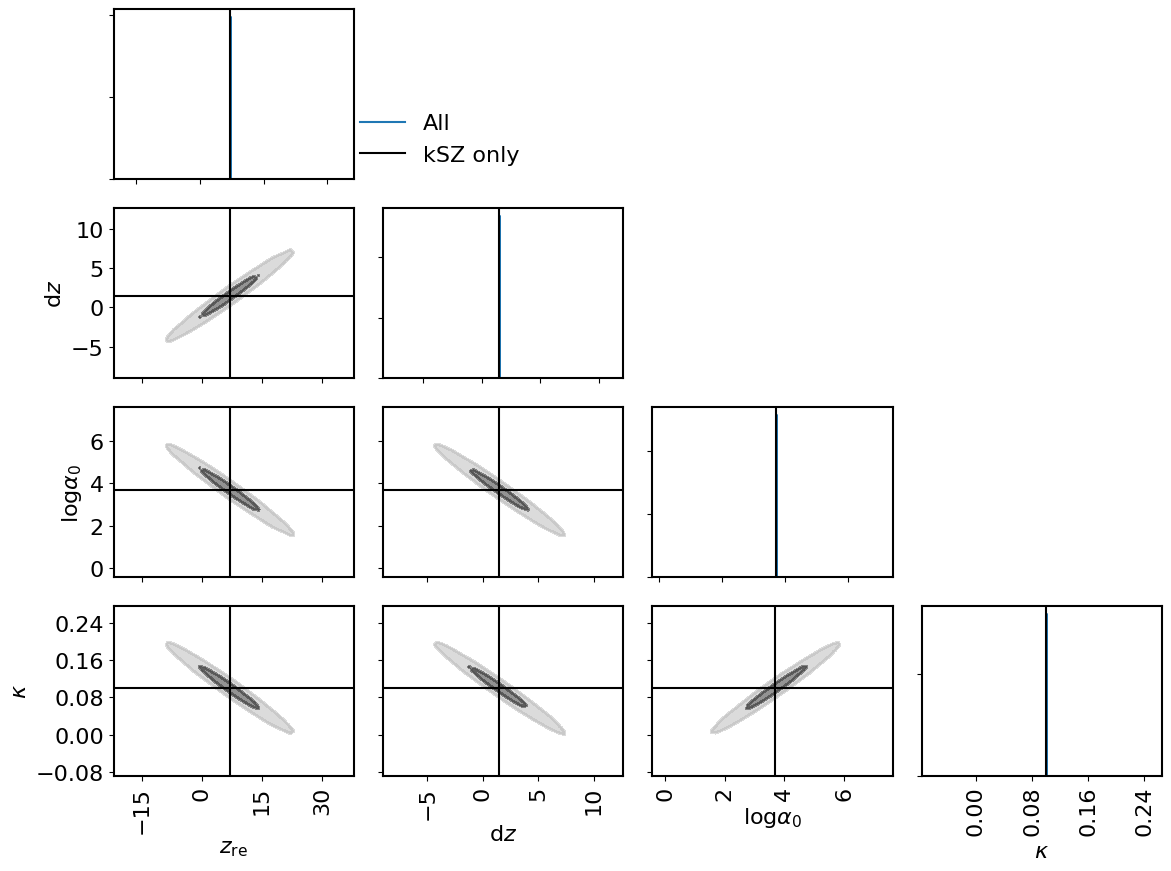

In [ ]:
bounds = [(0, 50), (0, 15), (0, 10), (0, 0.3)]
zorders = [0, 1, 2, 3]
fig, axes = plt.subplots(4, 4, figsize=(12, 9))
triangleme.corner(data_all,
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Blues', color='C0', lw=2., smooth=1., alpha=.5,
                  zorder=2, fig=fig)
# triangleme.corner(data_notau, 
#                   labels=theta_labels,
#                   sigmas=[1, 2], plot_datapoints=False, 
#                   cmap='Greys', color='k', lw=2., smooth=1., alpha=.5,
#                   zorder=1, 
                #   truths=theta_true, truth_color='k',
#                   fig=fig)
triangleme.corner(data_ksz, 
                  labels=theta_labels,
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greys', color='k', lw=2., smooth=1., alpha=.5,
                  zorder=1, 
                  truths=theta_true, truth_color='k',
                  fig=fig)
plt.plot([], [], color='C0', label='All')
plt.plot([], [], color='k', label=r'kSZ only')
fig.legend(loc=(0.3, 0.8), frameon=False)

fig.tight_layout()


/tmp/ipykernel_2848868/525475127.py:13: RuntimeWarning: invalid value encountered in divide
  axes[u].plot(xlin, gauss/gauss.max(), color=color, lw=2.)
/tmp/ipykernel_2848868/525475127.py:13: RuntimeWarning: invalid value encountered in divide
  axes[u].plot(xlin, gauss/gauss.max(), color=color, lw=2.)
/tmp/ipykernel_2848868/525475127.py:13: RuntimeWarning: invalid value encountered in divide
  axes[u].plot(xlin, gauss/gauss.max(), color=color, lw=2.)
/tmp/ipykernel_2848868/525475127.py:13: RuntimeWarning: invalid value encountered in divide
  axes[u].plot(xlin, gauss/gauss.max(), color=color, lw=2.)


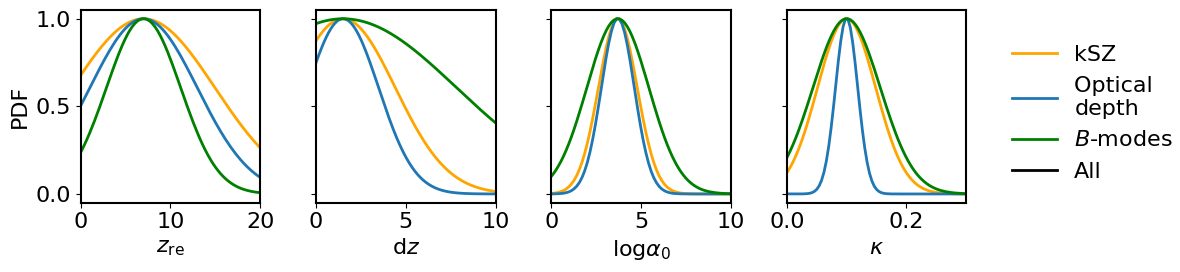

In [63]:
bounds = [(0, 20), (0, 10), (0, 10), (0, 0.3)]

fig, axes = plt.subplots(1, len(theta_labels)+1, figsize=(12, 3), gridspec_kw={'width_ratios':(1,1,1,1,0.7)}, sharey=True)
for i, (obs, fishmat, color) in enumerate(zip(
    ['kSZ', 'Optical \ndepth', r'$B$-modes', 'All'],
    fishcov_list+[fishcov_all],
    ['orange', 'C0', 'green', 'k'])):
    sigma_err = np.sqrt(np.diag(fishmat))
    for u, (label, sig) in enumerate(zip(theta_labels,sigma_err)):
        xlin = np.linspace(theta_true[u]*(-10), theta_true[u]*10, 500)
        gauss = np.exp(- (xlin-theta_true[u])**2/2./sig**2)
        # gauss /= (sig * np.sqrt(2.*np.pi))
        axes[u].plot(xlin, gauss/gauss.max(), color=color, lw=2.)
        axes[u].set_xlabel(label)
        axes[u].set_xlim(bounds[u])
    axes[-1].plot([], [], color=color, label=obs, lw=2.)
axes[0].set_ylabel('PDF')
axes[-1].set_visible(False)
fig.legend(loc=(0.85, 0.3), frameon=False)
fig.tight_layout()
# fig.savefig('figures/fisher_forecast_ideal_1D_posteriors.pdf', dpi=200)

kSZ [7.95252366 2.91462545 1.08000121 0.04861361]
Optical 
depth [5.98372674 1.98274876 0.91773433 0.01850999]
$B$-modes [4.13415659 6.32888896 1.72836488 0.05630329]
All [4.01175778e-06 5.89633321e-06 1.54225406e-06 4.96683942e-08]


/tmp/ipykernel_2848868/802216544.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['0']+theta_labels)


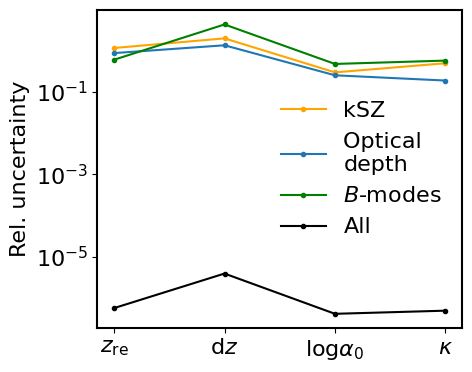

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
for i, (obs, fishmat, color) in enumerate(zip(
    ['kSZ', 'Optical \ndepth', r'$B$-modes', 'All'],
    fishcov_list+[fishcov_all],
    ['orange', 'C0', 'green', 'k'])):
    sigma_err = np.sqrt(np.diag(fishmat))
    print(obs, sigma_err)
    ax.semilogy(np.arange(4), sigma_err/theta_true, color=color, lw=1.5, label=obs, marker='.')
    # axes[u].set_xlabel(label)
ax.set_ylabel(r'Rel. uncertainty')
ax.legend(frameon=False)
ax.set_xticklabels(['0']+theta_labels)
fig.tight_layout()

22.90666789971423 0.36562316207547424 23.122971304135664
4.101739219998439 0.11956156136448189 4.280900001059928
26.74470920886 1.5210724695623277 25.997030903065703
2.3948640643724737e-11 1.4680759565128905 2.3627508828742054e-11


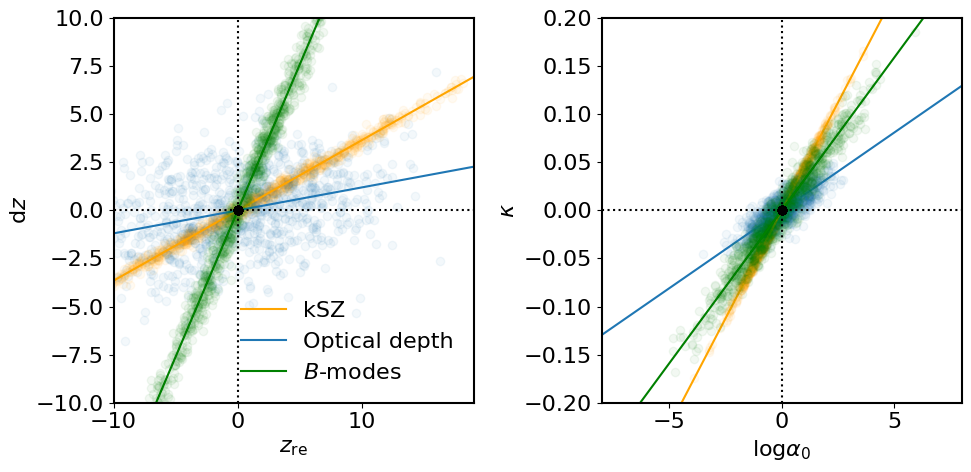

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, (obs, fishmat, data, color) in enumerate(zip(
    ['kSZ', r'Optical depth', r'$B$-modes', 'All'],
    fishcov_list+[fishcov_all],
    [data_ksz, data_tau, data_bb, data_all],
    ['orange', 'C0', 'green', 'k'])):

    xlin = np.linspace(theta_true[0]*(-10), theta_true[0]*10, 500)
    r = fishmat[0, 1] / fishmat[0, 0] #/ fishmat[1, 1]
    if i != 3:
        axes[0].plot(xlin, xlin * r, color=color, label=obs)
    axes[0].scatter(data[::10, 0]-theta_true[0], data[::10, 1]-theta_true[1], color=color, alpha=0.05, zorder=i)
    print(np.cov(data.T)[0, 1],  r, fishmat[0,1])

    xlin = np.linspace(theta_true[2]*(-10), theta_true[2]*10, 500)
    r = fishmat[2, 3] / fishmat[2, 2] #/ fishmat[3, 3]
    if i != 3:
        axes[1].plot(xlin, xlin * r, color=color, label=obs)
    axes[1].scatter(data[::10, 2]-theta_true[2], data[::10, 3]-theta_true[3], color=color, alpha=0.05, zorder=i)
axes[0].set_ylabel(theta_labels[1])
axes[0].set_xlabel(theta_labels[0])
axes[0].set_xlim(-10, 19)
axes[0].set_ylim(-10, 10)
axes[1].set_ylabel(theta_labels[3])
axes[1].set_xlabel(theta_labels[2])
axes[1].set_xlim(-8, 8)
axes[1].set_ylim(-0.2, 0.2)
axes[0].legend(frameon=False)
for i in range(2):
    axes[i].axvline(0, color='k', ls=':')
    axes[i].axhline(0, color='k', ls=':')
fig.tight_layout()

## Optical depth

In [118]:
preion_model = Pee_model(
    zre_h=theta_true[0], dz_h=theta_true[1],
    alpha0=theta_true[2], kappa=theta_true[3],
    h=cos.h, Ob_0=cos.Ob0, Om_0=cos.Om0,
    verbose=False, run_camb=False)

In [119]:
tau_obs = preion_model.tau
tau_err = 0.005
print(tau_obs)

0.06028504618933713


In [155]:
cov_tau_glob = np.array([[tau_err**2]])
icov_tau_glob = np.array([[1/tau_err**2]])

In [123]:
deriv_tau_glob_zre = dtau_dz(theta_true, idz=0, dev=dev)
deriv_tau_glob_dz = dtau_dz(theta_true, idz=1, dev=dev)

In [145]:
deriv_list_temp = get_derivatives(theta_true, ells, low_ells, run_derivatives=False, dev=dev)
deriv_list = [np.r_[l[0], d] for l, d in zip(deriv_list_temp[:2], [deriv_tau_glob_zre, deriv_tau_glob_dz])]

In [158]:
cov_list = [cov_ksz, cov_tau_glob]
cov_tot = np.diag( np.hstack([np.diag(cov) for cov in cov_list]) )
cov_tot.shape

(20, 20)

In [163]:
cov_list = [cov_ksz, cov_tau_glob]
cov_ksz_tau = np.diag( np.hstack([np.diag(cov) for cov in cov_list]) )
icov_ksz_tau = np.linalg.inv(cov_ksz_tau)

# derivatives
deriv_list_temp = get_derivatives(theta_true, ells, low_ells, run_derivatives=False, dev=dev)
deriv_list = [np.r_[l[0], d] for l, d in zip(deriv_list_temp[:2], [deriv_tau_glob_zre, deriv_tau_glob_dz])]

fish_ksz_tau = np.zeros((len(theta_true)-2, len(theta_true)-2))
for i, deriv in enumerate([np.hstack(l) for l in deriv_list]):
    for j, deriv2 in enumerate([np.hstack(l) for l in deriv_list]):
        fish_ksz_tau[i, j] = np.transpose(deriv).dot(icov_tot).dot(deriv2)
fishcov_ksz_tau = np.linalg.inv(fish_ksz_tau)

data_ksz_tau = np.random.multivariate_normal(theta_true[:2], fishcov_ksz_tau, size=nsamples)

In [125]:
# fish_tau_glob = np.zeros((2,2))
# for i, deriv in enumerate([deriv_tau_glob_zre, deriv_tau_glob_dz]):
#     for j, deriv2 in enumerate([deriv_tau_glob_zre, deriv_tau_glob_dz]):
#         fish_tau_glob[i, j] = deriv*deriv2 * icov_tau_glob[0]
# det = fish_tau_glob[0,0]*fish_tau_glob[1,1]-fish_tau_glob[1,0]**2
# print(det)

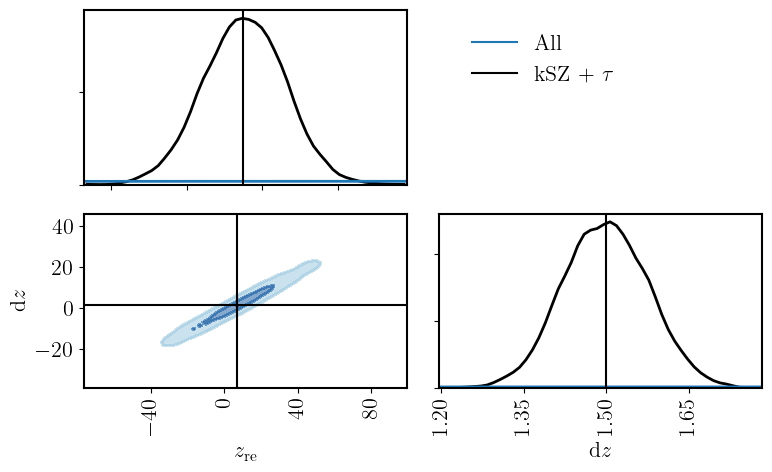

In [170]:
# bounds = [(0, 50), (0, 15), (0, 10), (0, 0.3)]
fig, axes = plt.subplots(2, 2, figsize=(8, 5))
triangleme.corner(data_all[:, :2],
                  labels=theta_labels[:2],
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Blues', color='C0', lw=2., smooth=1., alpha=.5,
                  zorder=2, fig=fig)
triangleme.corner(data_ksz_tau, 
                  labels=theta_labels[:2],
                  sigmas=[1, 2], plot_datapoints=False, 
                  cmap='Greys', color='k', lw=2., smooth=1., alpha=.5,
                  zorder=1, 
                  truths=theta_true[:2], truth_color='k',
                  fig=fig)
plt.plot([], [], color='C0', label='All')
plt.plot([], [], color='k', label=r'kSZ + $\tau$')
fig.legend(loc=(0.6, 0.8), frameon=False)

fig.tight_layout()


## Investigating the correlation

We want to inverstigate why the correlation between $z_\mathrm{re}$ and $z_\mathrm{end}$ is so strong. This correlation is related to the off-diagonal term of the covariance matrix, which we can obtain analytically when inverting the Fisher matrix.

We can derive the inversion of a two-dimensional square matrix analytically:
\begin{equation}
\begin{pmatrix}
a & b \\
b & c
\end{pmatrix}^{-1} = \frac{1}{ac-b^2}
\begin{pmatrix}
c & -b \\
-b & a
\end{pmatrix}
\end{equation}

If we take the inversion of $\mathcal{F}$, the correlation level is given by the off-diagonal term
\begin{equation}
b = \frac{\partial \mathbf{o}^T}{\partial z_\mathrm{re}}\mathbf{\Pi}^{-1}\frac{\partial \mathbf{o}}{\partial z_\mathrm{end}} = \sum_{k,j} \frac{\partial o_j}{\partial z_\mathrm{re}} \frac{\partial o_k}{\partial z_\mathrm{end}} \Pi^{-1}_{jk}
\end{equation}

Let's compute the contribution of these different terms to the correlation.

-86.42647370635841
[[-1.48479311e+00 -1.02531292e-03 -1.12996807e+00]
 [-4.28331217e-04 -4.62635314e-01  3.09147381e-01]
 [-4.27463182e-01  2.79946356e-01 -8.35092541e+01]]


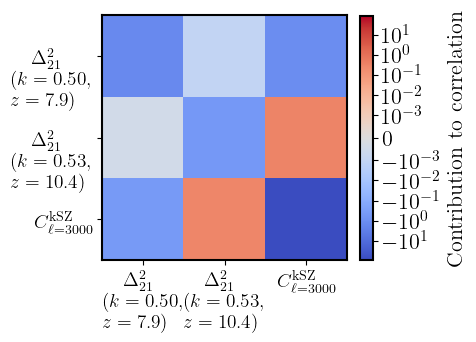

In [151]:
B = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        B[i, j] += deriv_zre[i]*deriv_zend[j]*mcmc.icov[i, j]
print(np.sum(B))
print(B)


labels = [r"$\Delta^2_{21}\\(k=%.2f,\\z=%.1f)$" %(k,z) for (k, z) in zip(mcmc.k_data, mcmc.z_data)]
labels.extend([r'$C^\mathrm{kSZ}_{\ell=%i}$' %mcmc.ells_data])
dataset_length = np.r_[mcmc.ells_data, mcmc.k_data].size

norm = colors.LogNorm(mcmc.cov.min(), mcmc.cov.max())
fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
im = ax.imshow(B, cmap='coolwarm', norm=colors.SymLogNorm(1e-3, vmin=-np.abs(B).max(), vmax=np.abs(B).max()),
               extent=(0, dataset_length, dataset_length, 0))
ax.set_xticks(np.arange(0.5, dataset_length, step=1.),
              labels=labels, fontsize=14)
ax.set_yticks(np.arange(0.5, dataset_length, step=1.),
              labels=labels, fontsize=14)
# ax.set_title(titles[u], fontsize=15)
cbar = plt.colorbar(im, ax=ax, fraction=0.045, label=r'Contribution to correlation')
fig.tight_layout()

The high correlation comes from the bottom-right term of the matrix. Looking at how the inverse of a (3,3) matrix is computed, we find, for
\begin{equation}
A = \begin{pmatrix}
a & b & c \\
d & e & f \\
g & h & i
\end{pmatrix}
\end{equation}
that the [3, 3] term of $A^{-1}$ is $A^{-1}_{3,3}=\frac{ad-bc}{\mathrm{det}(A)}$. So the strong correlation comes from the top-left block matrix of $\mathbf{\Pi}$, i.e. from the error bars and correlations between the 21\,cm data points.